# Exploratory Data Analysis (EDA) Profundo - Dataset Curves

## Parte 3: Analisis Geometrico y de Formas

Este notebook analiza las propiedades geometricas de las curvas: longitudes, curvatura, pendientes, velocidades y patrones de forma.

---

### Tabla de Contenidos
1. Longitud de Curvas (Arc Length)
2. Analisis de Curvatura
3. Analisis de Pendientes y Derivadas
4. Velocidades Parametricas
5. Deteccion de Patrones de Forma
6. Clasificacion de Tipos de Curvas
7. Analisis de Puntos Criticos

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from pathlib import Path
from scipy import signal
from scipy.ndimage import gaussian_filter1d
import warnings
warnings.filterwarnings('ignore')

# Configuracion
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = [14, 6]
plt.rcParams['font.size'] = 10

# Rutas
BASE_PATH = Path('..')
PIXEL_CURVES_PATH = BASE_PATH / 'datos' / 'pixel_curves'
TARGET_PATH = BASE_PATH / 'datos' / 'target'

print("Librerias cargadas")

Librerias cargadas


In [2]:
# Funciones de carga
def load_target_curve(curve_id):
    filepath = TARGET_PATH / f'curve_{curve_id:04d}.txt'
    data = np.loadtxt(filepath, delimiter=',')
    return data[:, 0], data[:, 1]

def load_pixel_curve(curve_id, x_value):
    filepath = PIXEL_CURVES_PATH / f'curve_{curve_id:04d}_X{x_value}.txt'
    data = np.loadtxt(filepath)
    return data[:, 0], data[:, 1]

# Cargar datos
print("Cargando curvas target...")
target_data = {}
for i in range(1, 501):
    x, y = load_target_curve(i)
    target_data[i] = {'x': x, 'y': y}
print(f"Cargadas: {len(target_data)} curvas")

Cargando curvas target...
Cargadas: 500 curvas


---
## 1. Longitud de Curvas (Arc Length)

In [3]:
def calculate_arc_length(x, y):
    """Calcula la longitud de arco de una curva."""
    dx = np.diff(x)
    dy = np.diff(y)
    segment_lengths = np.sqrt(dx**2 + dy**2)
    return np.sum(segment_lengths)

def calculate_cumulative_arc_length(x, y):
    """Calcula la longitud de arco acumulativa."""
    dx = np.diff(x)
    dy = np.diff(y)
    segment_lengths = np.sqrt(dx**2 + dy**2)
    return np.concatenate([[0], np.cumsum(segment_lengths)])

print("ANALISIS DE LONGITUD DE CURVAS")
print("=" * 70)

# Calcular longitudes para todas las curvas
arc_lengths = []
for curve_id, data in target_data.items():
    length = calculate_arc_length(data['x'], data['y'])
    arc_lengths.append({'curve_id': curve_id, 'arc_length': length})

df_lengths = pd.DataFrame(arc_lengths)

print("\nEstadisticas de longitud de arco (Target):")
print(f"  Media: {df_lengths['arc_length'].mean():.2f}")
print(f"  Mediana: {df_lengths['arc_length'].median():.2f}")
print(f"  Std: {df_lengths['arc_length'].std():.2f}")
print(f"  Min: {df_lengths['arc_length'].min():.2f} (Curva {df_lengths.loc[df_lengths['arc_length'].idxmin(), 'curve_id']})")
print(f"  Max: {df_lengths['arc_length'].max():.2f} (Curva {df_lengths.loc[df_lengths['arc_length'].idxmax(), 'curve_id']})")

ANALISIS DE LONGITUD DE CURVAS

Estadisticas de longitud de arco (Target):
  Media: 228.52
  Mediana: 232.71
  Std: 90.69
  Min: 59.58 (Curva 413)
  Max: 425.18 (Curva 328)


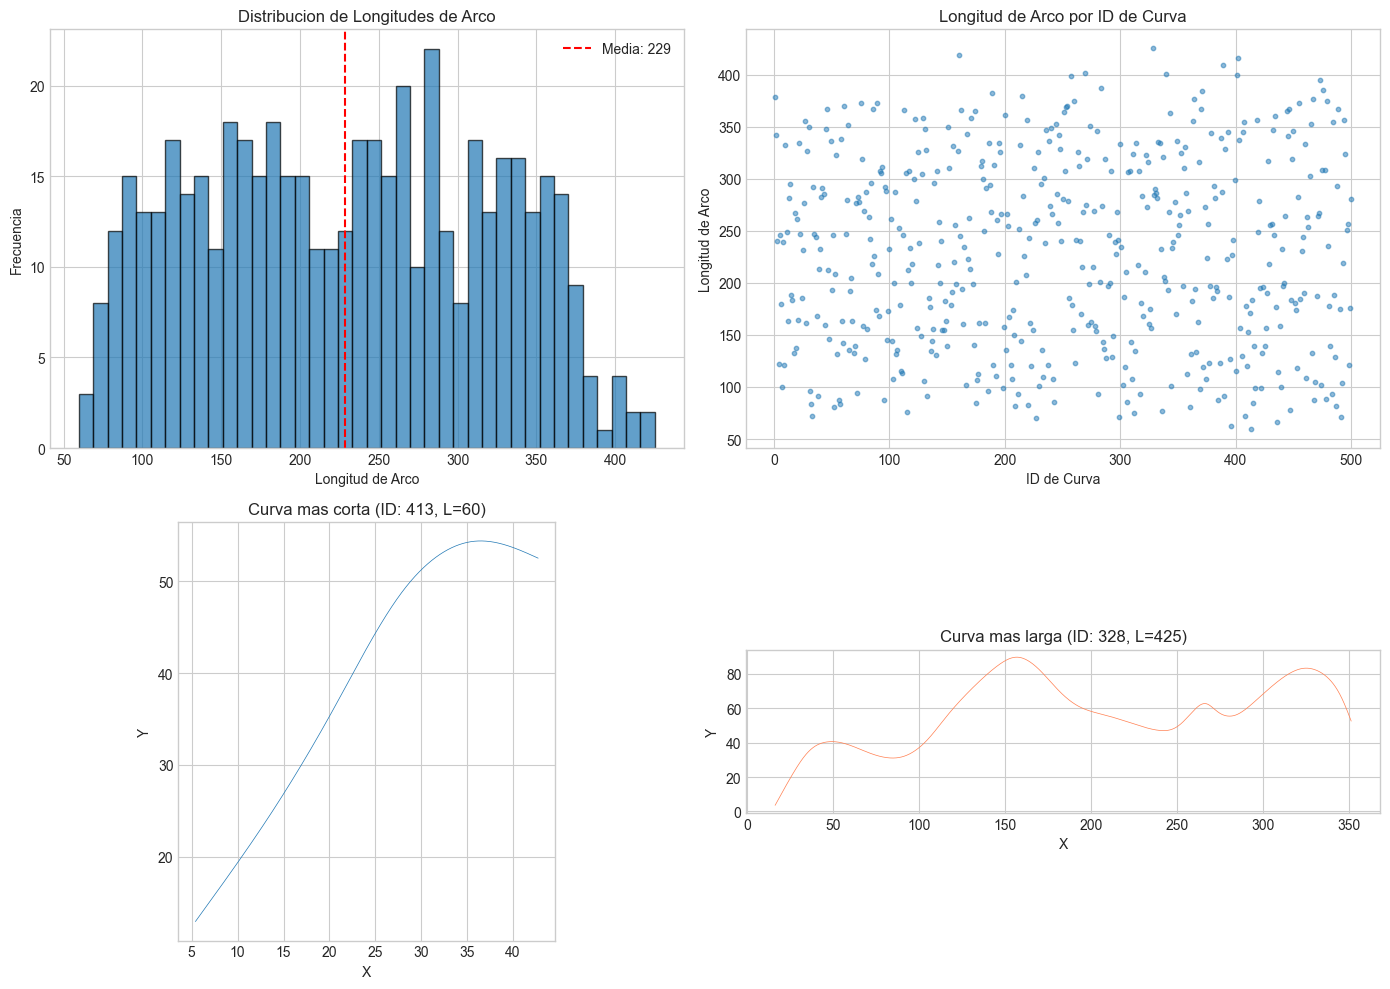

In [4]:
# Visualizacion de longitudes
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histograma de longitudes
axes[0, 0].hist(df_lengths['arc_length'], bins=40, edgecolor='black', alpha=0.7)
axes[0, 0].axvline(df_lengths['arc_length'].mean(), color='red', linestyle='--', label=f'Media: {df_lengths["arc_length"].mean():.0f}')
axes[0, 0].set_title('Distribucion de Longitudes de Arco')
axes[0, 0].set_xlabel('Longitud de Arco')
axes[0, 0].set_ylabel('Frecuencia')
axes[0, 0].legend()

# Longitud por ID de curva
axes[0, 1].scatter(df_lengths['curve_id'], df_lengths['arc_length'], alpha=0.5, s=10)
axes[0, 1].set_title('Longitud de Arco por ID de Curva')
axes[0, 1].set_xlabel('ID de Curva')
axes[0, 1].set_ylabel('Longitud de Arco')

# Curva mas corta
shortest_id = df_lengths.loc[df_lengths['arc_length'].idxmin(), 'curve_id']
x, y = target_data[shortest_id]['x'], target_data[shortest_id]['y']
axes[1, 0].plot(x, y, linewidth=0.5)
axes[1, 0].set_title(f'Curva mas corta (ID: {shortest_id}, L={df_lengths["arc_length"].min():.0f})')
axes[1, 0].set_xlabel('X')
axes[1, 0].set_ylabel('Y')
axes[1, 0].set_aspect('equal')

# Curva mas larga
longest_id = df_lengths.loc[df_lengths['arc_length'].idxmax(), 'curve_id']
x, y = target_data[longest_id]['x'], target_data[longest_id]['y']
axes[1, 1].plot(x, y, linewidth=0.5, color='coral')
axes[1, 1].set_title(f'Curva mas larga (ID: {longest_id}, L={df_lengths["arc_length"].max():.0f})')
axes[1, 1].set_xlabel('X')
axes[1, 1].set_ylabel('Y')
axes[1, 1].set_aspect('equal')

plt.tight_layout()
plt.savefig('longitudes_curvas.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 2. Analisis de Curvatura

In [5]:
def calculate_curvature(x, y, smooth_sigma=5):
    """Calcula la curvatura de una curva parametrica.
    
    Curvatura kappa = |x'y'' - y'x''| / (x'^2 + y'^2)^(3/2)
    """
    # Suavizar para evitar ruido en derivadas
    x_smooth = gaussian_filter1d(x, sigma=smooth_sigma)
    y_smooth = gaussian_filter1d(y, sigma=smooth_sigma)
    
    # Primera derivada
    dx = np.gradient(x_smooth)
    dy = np.gradient(y_smooth)
    
    # Segunda derivada
    ddx = np.gradient(dx)
    ddy = np.gradient(dy)
    
    # Curvatura
    numerator = np.abs(dx * ddy - dy * ddx)
    denominator = (dx**2 + dy**2)**(1.5)
    
    # Evitar division por cero
    denominator[denominator < 1e-10] = 1e-10
    
    curvature = numerator / denominator
    return curvature

print("ANALISIS DE CURVATURA")
print("=" * 70)

# Calcular curvatura para todas las curvas
curvature_stats = []

for curve_id, data in target_data.items():
    curvature = calculate_curvature(data['x'], data['y'])
    
    stats_dict = {
        'curve_id': curve_id,
        'curvature_mean': np.mean(curvature),
        'curvature_max': np.max(curvature),
        'curvature_std': np.std(curvature),
        'curvature_median': np.median(curvature),
        'curvature_q95': np.percentile(curvature, 95)
    }
    curvature_stats.append(stats_dict)

df_curvature = pd.DataFrame(curvature_stats)

print("\nEstadisticas de curvatura:")
print(df_curvature.describe().round(4).to_string())

ANALISIS DE CURVATURA

Estadisticas de curvatura:
       curve_id  curvature_mean  curvature_max  curvature_std  curvature_median  curvature_q95
count  500.0000        500.0000       500.0000       500.0000          500.0000       500.0000
mean   250.5000          0.0304         0.1596         0.0325            0.0196         0.0998
std    144.4818          0.0092         0.0890         0.0138            0.0061         0.0398
min      1.0000          0.0078         0.0262         0.0069            0.0030         0.0230
25%    125.7500          0.0240         0.0943         0.0227            0.0152         0.0729
50%    250.5000          0.0300         0.1390         0.0303            0.0197         0.0939
75%    375.2500          0.0359         0.2030         0.0403            0.0236         0.1238
max    500.0000          0.0618         0.5026         0.0785            0.0410         0.2645


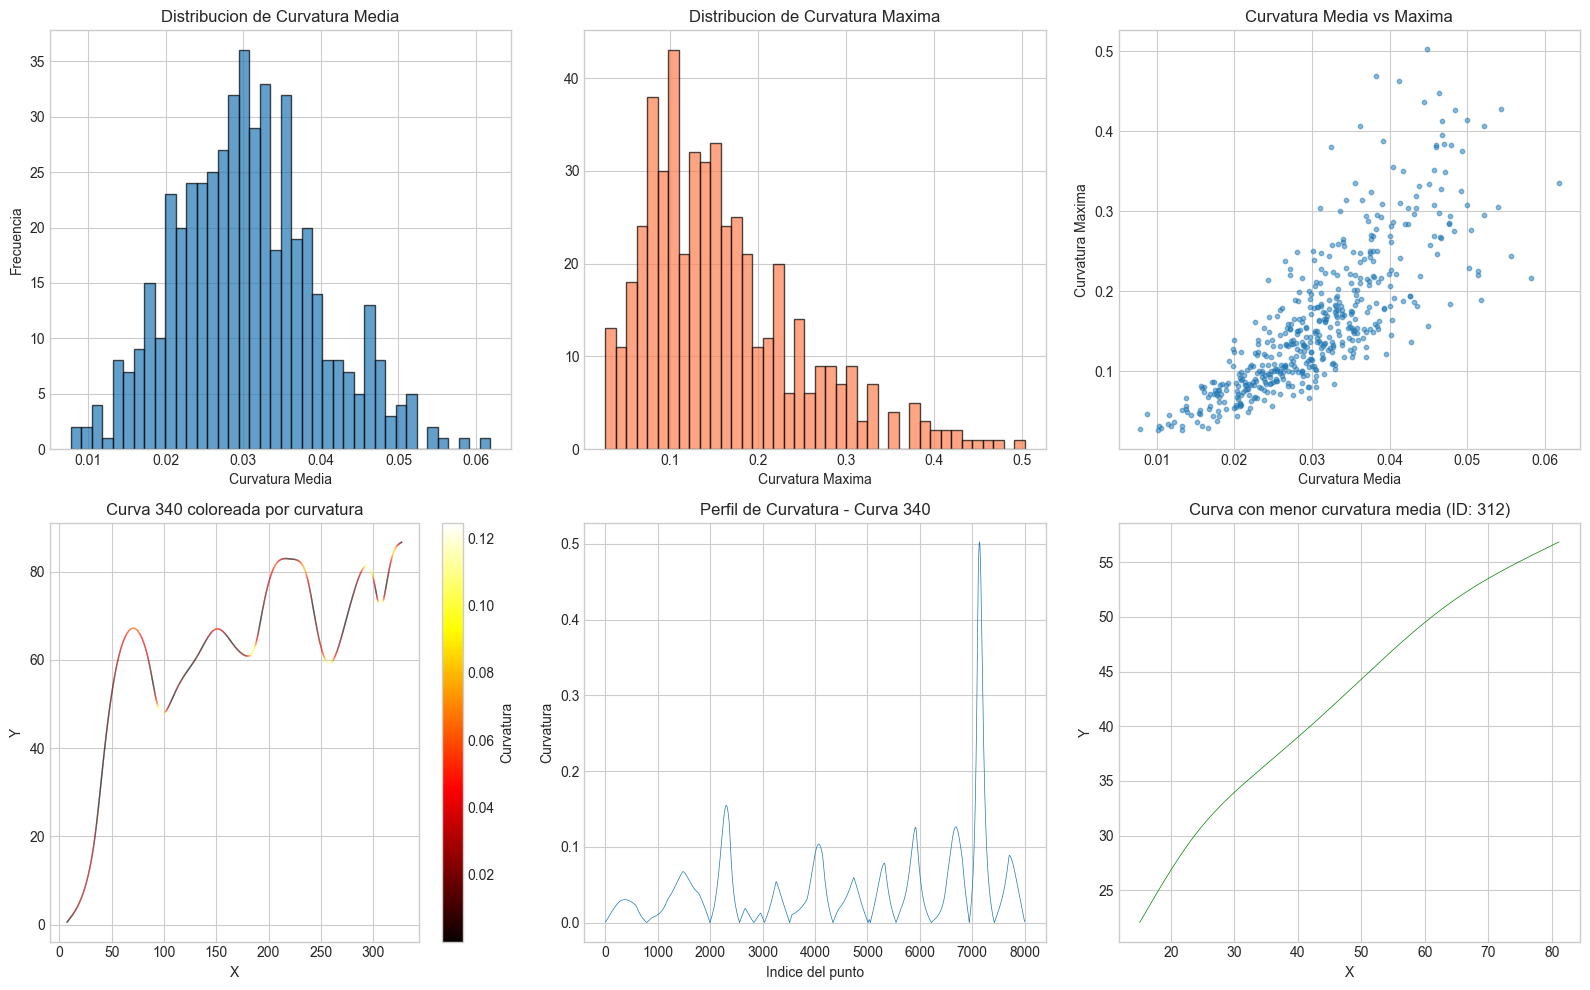

In [6]:
# Visualizacion de curvatura
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Histograma de curvatura media
axes[0, 0].hist(df_curvature['curvature_mean'], bins=40, edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Distribucion de Curvatura Media')
axes[0, 0].set_xlabel('Curvatura Media')
axes[0, 0].set_ylabel('Frecuencia')

# Histograma de curvatura maxima
axes[0, 1].hist(df_curvature['curvature_max'], bins=40, edgecolor='black', alpha=0.7, color='coral')
axes[0, 1].set_title('Distribucion de Curvatura Maxima')
axes[0, 1].set_xlabel('Curvatura Maxima')

# Relacion curvatura media vs max
axes[0, 2].scatter(df_curvature['curvature_mean'], df_curvature['curvature_max'], alpha=0.5, s=10)
axes[0, 2].set_title('Curvatura Media vs Maxima')
axes[0, 2].set_xlabel('Curvatura Media')
axes[0, 2].set_ylabel('Curvatura Maxima')

# Ejemplo: curva con alta curvatura
high_curv_id = df_curvature.loc[df_curvature['curvature_max'].idxmax(), 'curve_id']
x, y = target_data[high_curv_id]['x'], target_data[high_curv_id]['y']
curvature = calculate_curvature(x, y)

# Colorear por curvatura
points = np.array([x, y]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)
from matplotlib.collections import LineCollection
norm = plt.Normalize(curvature.min(), np.percentile(curvature, 95))
lc = LineCollection(segments, cmap='hot', norm=norm)
lc.set_array(curvature[:-1])
lc.set_linewidth(1)
axes[1, 0].add_collection(lc)
axes[1, 0].autoscale()
axes[1, 0].set_title(f'Curva {high_curv_id} coloreada por curvatura')
axes[1, 0].set_xlabel('X')
axes[1, 0].set_ylabel('Y')
plt.colorbar(lc, ax=axes[1, 0], label='Curvatura')

# Curvatura a lo largo de la curva
axes[1, 1].plot(curvature, linewidth=0.5)
axes[1, 1].set_title(f'Perfil de Curvatura - Curva {high_curv_id}')
axes[1, 1].set_xlabel('Indice del punto')
axes[1, 1].set_ylabel('Curvatura')

# Comparativa: curva baja curvatura
low_curv_id = df_curvature.loc[df_curvature['curvature_mean'].idxmin(), 'curve_id']
x, y = target_data[low_curv_id]['x'], target_data[low_curv_id]['y']
axes[1, 2].plot(x, y, linewidth=0.5, color='green')
axes[1, 2].set_title(f'Curva con menor curvatura media (ID: {low_curv_id})')
axes[1, 2].set_xlabel('X')
axes[1, 2].set_ylabel('Y')

plt.tight_layout()
plt.savefig('curvatura_analisis.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3. Analisis de Pendientes y Derivadas

In [7]:
def calculate_slopes(x, y):
    """Calcula las pendientes (dy/dx) a lo largo de la curva."""
    dx = np.diff(x)
    dy = np.diff(y)
    
    # Evitar division por cero
    dx[dx == 0] = 1e-10
    
    slopes = dy / dx
    return slopes

def calculate_angles(x, y):
    """Calcula los angulos de direccion (en grados) a lo largo de la curva."""
    dx = np.diff(x)
    dy = np.diff(y)
    angles = np.arctan2(dy, dx) * 180 / np.pi
    return angles

print("ANALISIS DE PENDIENTES Y ANGULOS")
print("=" * 70)

# Calcular estadisticas de pendientes
slope_stats = []

for curve_id, data in target_data.items():
    slopes = calculate_slopes(data['x'], data['y'])
    angles = calculate_angles(data['x'], data['y'])
    
    # Filtrar valores extremos de pendiente
    slopes_clean = slopes[np.abs(slopes) < 100]
    
    stats_dict = {
        'curve_id': curve_id,
        'slope_mean': np.mean(slopes_clean) if len(slopes_clean) > 0 else 0,
        'slope_std': np.std(slopes_clean) if len(slopes_clean) > 0 else 0,
        'angle_mean': np.mean(angles),
        'angle_std': np.std(angles),
        'angle_range': np.max(angles) - np.min(angles),
        'direction_changes': np.sum(np.diff(np.sign(angles)) != 0)
    }
    slope_stats.append(stats_dict)

df_slopes = pd.DataFrame(slope_stats)

print("\nEstadisticas de pendientes:")
print(df_slopes[['slope_mean', 'slope_std', 'angle_mean', 'angle_std', 'angle_range', 'direction_changes']].describe().round(4).to_string())

ANALISIS DE PENDIENTES Y ANGULOS

Estadisticas de pendientes:
       slope_mean  slope_std  angle_mean  angle_std  angle_range  direction_changes
count    500.0000   500.0000    500.0000   500.0000     500.0000           500.0000
mean       0.3126     0.7389     12.3620    29.7680      99.4802             4.2080
std        0.2405     0.2423      9.1257     7.2415      22.2182             2.5039
min       -0.5356     0.1308    -17.0494     6.9096      25.8273             0.0000
25%        0.1482     0.5785      6.1708    25.7332      87.2509             2.0000
50%        0.2711     0.7211     10.4954    30.3620     103.3607             4.0000
75%        0.4141     0.8700     16.5084    34.4288     114.8218             6.0000
max        1.4335     1.7546     50.9985    48.9192     142.3964            12.0000


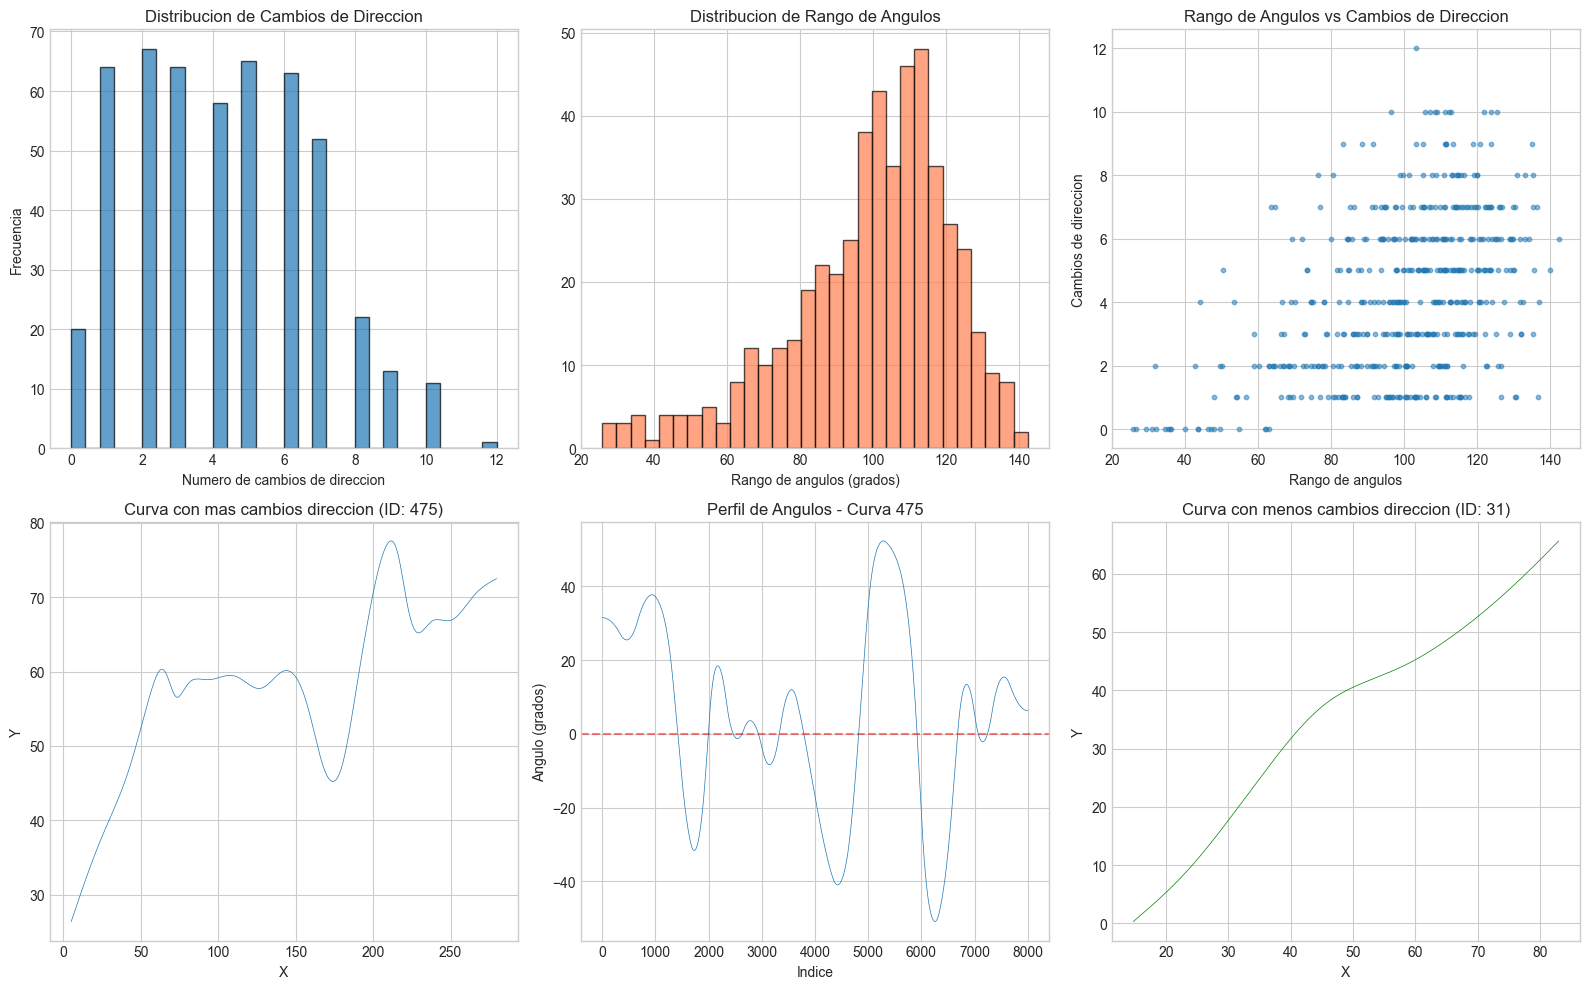

In [8]:
# Visualizacion de analisis de direccion
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Distribucion de cambios de direccion
axes[0, 0].hist(df_slopes['direction_changes'], bins=30, edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Distribucion de Cambios de Direccion')
axes[0, 0].set_xlabel('Numero de cambios de direccion')
axes[0, 0].set_ylabel('Frecuencia')

# Distribucion de rango de angulos
axes[0, 1].hist(df_slopes['angle_range'], bins=30, edgecolor='black', alpha=0.7, color='coral')
axes[0, 1].set_title('Distribucion de Rango de Angulos')
axes[0, 1].set_xlabel('Rango de angulos (grados)')

# Relacion cambios vs rango
axes[0, 2].scatter(df_slopes['angle_range'], df_slopes['direction_changes'], alpha=0.5, s=10)
axes[0, 2].set_title('Rango de Angulos vs Cambios de Direccion')
axes[0, 2].set_xlabel('Rango de angulos')
axes[0, 2].set_ylabel('Cambios de direccion')

# Ejemplo: curva con muchos cambios
many_changes_id = df_slopes.loc[df_slopes['direction_changes'].idxmax(), 'curve_id']
x, y = target_data[many_changes_id]['x'], target_data[many_changes_id]['y']
angles = calculate_angles(x, y)

axes[1, 0].plot(x, y, linewidth=0.5)
axes[1, 0].set_title(f'Curva con mas cambios direccion (ID: {many_changes_id})')
axes[1, 0].set_xlabel('X')
axes[1, 0].set_ylabel('Y')

# Perfil de angulos
axes[1, 1].plot(angles, linewidth=0.5)
axes[1, 1].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[1, 1].set_title(f'Perfil de Angulos - Curva {many_changes_id}')
axes[1, 1].set_xlabel('Indice')
axes[1, 1].set_ylabel('Angulo (grados)')

# Curva con pocos cambios
few_changes_id = df_slopes.loc[df_slopes['direction_changes'].idxmin(), 'curve_id']
x, y = target_data[few_changes_id]['x'], target_data[few_changes_id]['y']
axes[1, 2].plot(x, y, linewidth=0.5, color='green')
axes[1, 2].set_title(f'Curva con menos cambios direccion (ID: {few_changes_id})')
axes[1, 2].set_xlabel('X')
axes[1, 2].set_ylabel('Y')

plt.tight_layout()
plt.savefig('pendientes_direccion.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Velocidades Parametricas

In [9]:
def calculate_parametric_speed(x, y):
    """Calcula la velocidad parametrica (magnitud del vector tangente)."""
    dx = np.gradient(x)
    dy = np.gradient(y)
    speed = np.sqrt(dx**2 + dy**2)
    return speed

print("ANALISIS DE VELOCIDAD PARAMETRICA")
print("=" * 70)
print("\nLa velocidad parametrica mide que tan 'rapido' se mueve el punto")
print("a lo largo de la curva respecto al parametro t.")

# Calcular velocidades
speed_stats = []

for curve_id, data in target_data.items():
    speed = calculate_parametric_speed(data['x'], data['y'])
    
    stats_dict = {
        'curve_id': curve_id,
        'speed_mean': np.mean(speed),
        'speed_std': np.std(speed),
        'speed_min': np.min(speed),
        'speed_max': np.max(speed),
        'speed_cv': np.std(speed) / np.mean(speed) if np.mean(speed) > 0 else 0  # Coef. de variacion
    }
    speed_stats.append(stats_dict)

df_speed = pd.DataFrame(speed_stats)

print("\nEstadisticas de velocidad parametrica:")
print(df_speed.describe().round(6).to_string())

ANALISIS DE VELOCIDAD PARAMETRICA

La velocidad parametrica mide que tan 'rapido' se mueve el punto
a lo largo de la curva respecto al parametro t.

Estadisticas de velocidad parametrica:
         curve_id  speed_mean   speed_std   speed_min   speed_max    speed_cv
count  500.000000  500.000000  500.000000  500.000000  500.000000  500.000000
mean   250.500000    0.028569    0.007472    0.016180    0.046316    0.259349
std    144.481833    0.011338    0.003573    0.006074    0.021516    0.069603
min      1.000000    0.007449    0.000874    0.004543    0.009507    0.080692
25%    125.750000    0.019323    0.004609    0.011472    0.027948    0.208630
50%    250.500000    0.029092    0.007244    0.015733    0.045709    0.254544
75%    375.250000    0.038351    0.010050    0.020843    0.062958    0.300311
max    500.000000    0.053157    0.017447    0.036246    0.112542    0.600823


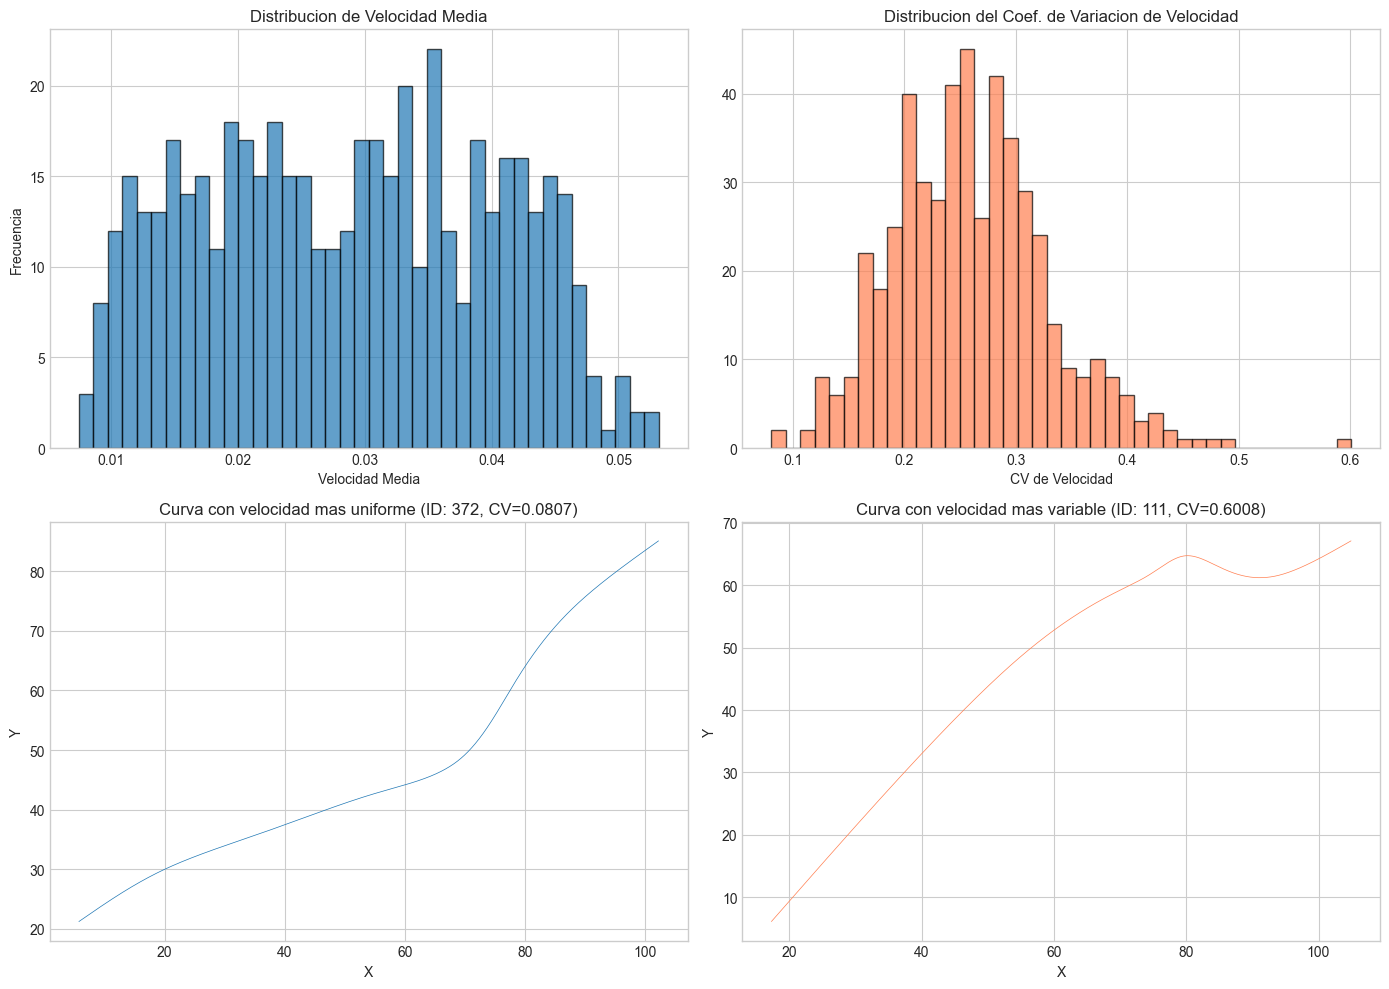

In [10]:
# Visualizacion de velocidades
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Distribucion de velocidad media
axes[0, 0].hist(df_speed['speed_mean'], bins=40, edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Distribucion de Velocidad Media')
axes[0, 0].set_xlabel('Velocidad Media')
axes[0, 0].set_ylabel('Frecuencia')

# Coeficiente de variacion
axes[0, 1].hist(df_speed['speed_cv'], bins=40, edgecolor='black', alpha=0.7, color='coral')
axes[0, 1].set_title('Distribucion del Coef. de Variacion de Velocidad')
axes[0, 1].set_xlabel('CV de Velocidad')

# Curva con velocidad mas uniforme (menor CV)
uniform_id = df_speed.loc[df_speed['speed_cv'].idxmin(), 'curve_id']
x, y = target_data[uniform_id]['x'], target_data[uniform_id]['y']
speed = calculate_parametric_speed(x, y)

ax1 = axes[1, 0]
ax1.plot(x, y, linewidth=0.5)
ax1.set_title(f'Curva con velocidad mas uniforme (ID: {uniform_id}, CV={df_speed["speed_cv"].min():.4f})')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')

# Curva con velocidad mas variable (mayor CV)
variable_id = df_speed.loc[df_speed['speed_cv'].idxmax(), 'curve_id']
x, y = target_data[variable_id]['x'], target_data[variable_id]['y']
speed = calculate_parametric_speed(x, y)

ax2 = axes[1, 1]
ax2.plot(x, y, linewidth=0.5, color='coral')
ax2.set_title(f'Curva con velocidad mas variable (ID: {variable_id}, CV={df_speed["speed_cv"].max():.4f})')
ax2.set_xlabel('X')
ax2.set_ylabel('Y')

plt.tight_layout()
plt.savefig('velocidad_parametrica.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Deteccion de Patrones de Forma

In [11]:
def classify_curve_type(x, y):
    """Clasifica una curva segun su patron de forma."""
    # Calcular caracteristicas
    angles = calculate_angles(x, y)
    curvature = calculate_curvature(x, y)
    
    # Detectar si es cerrada
    start_point = np.array([x[0], y[0]])
    end_point = np.array([x[-1], y[-1]])
    is_closed = np.linalg.norm(start_point - end_point) < 10  # Umbral
    
    # Detectar si tiene loops (cruce consigo misma)
    # Simplificado: verificar si la direccion cambia drasticamente
    angle_diff = np.diff(angles)
    has_loops = np.sum(np.abs(angle_diff) > 150) > 0
    
    # Detectar monotonia
    is_monotonic_x = np.all(np.diff(x) >= 0) or np.all(np.diff(x) <= 0)
    is_monotonic_y = np.all(np.diff(y) >= 0) or np.all(np.diff(y) <= 0)
    
    # Detectar oscilaciones
    y_peaks, _ = signal.find_peaks(y)
    y_valleys, _ = signal.find_peaks(-y)
    n_oscillations = min(len(y_peaks), len(y_valleys))
    
    # Clasificar
    if is_closed:
        return 'cerrada'
    elif has_loops:
        return 'con_loops'
    elif n_oscillations > 5:
        return 'oscilante'
    elif is_monotonic_x and is_monotonic_y:
        return 'monotonica'
    else:
        return 'abierta_compleja'

print("CLASIFICACION DE TIPOS DE CURVAS")
print("=" * 70)

# Clasificar todas las curvas
curve_types = []
for curve_id, data in target_data.items():
    curve_type = classify_curve_type(data['x'], data['y'])
    curve_types.append({'curve_id': curve_id, 'type': curve_type})

df_types = pd.DataFrame(curve_types)

print("\nDistribucion de tipos de curvas:")
type_counts = df_types['type'].value_counts()
for curve_type, count in type_counts.items():
    print(f"  {curve_type}: {count} ({count/len(df_types)*100:.1f}%)")

CLASIFICACION DE TIPOS DE CURVAS

Distribucion de tipos de curvas:
  abierta_compleja: 479 (95.8%)
  monotonica: 20 (4.0%)
  oscilante: 1 (0.2%)


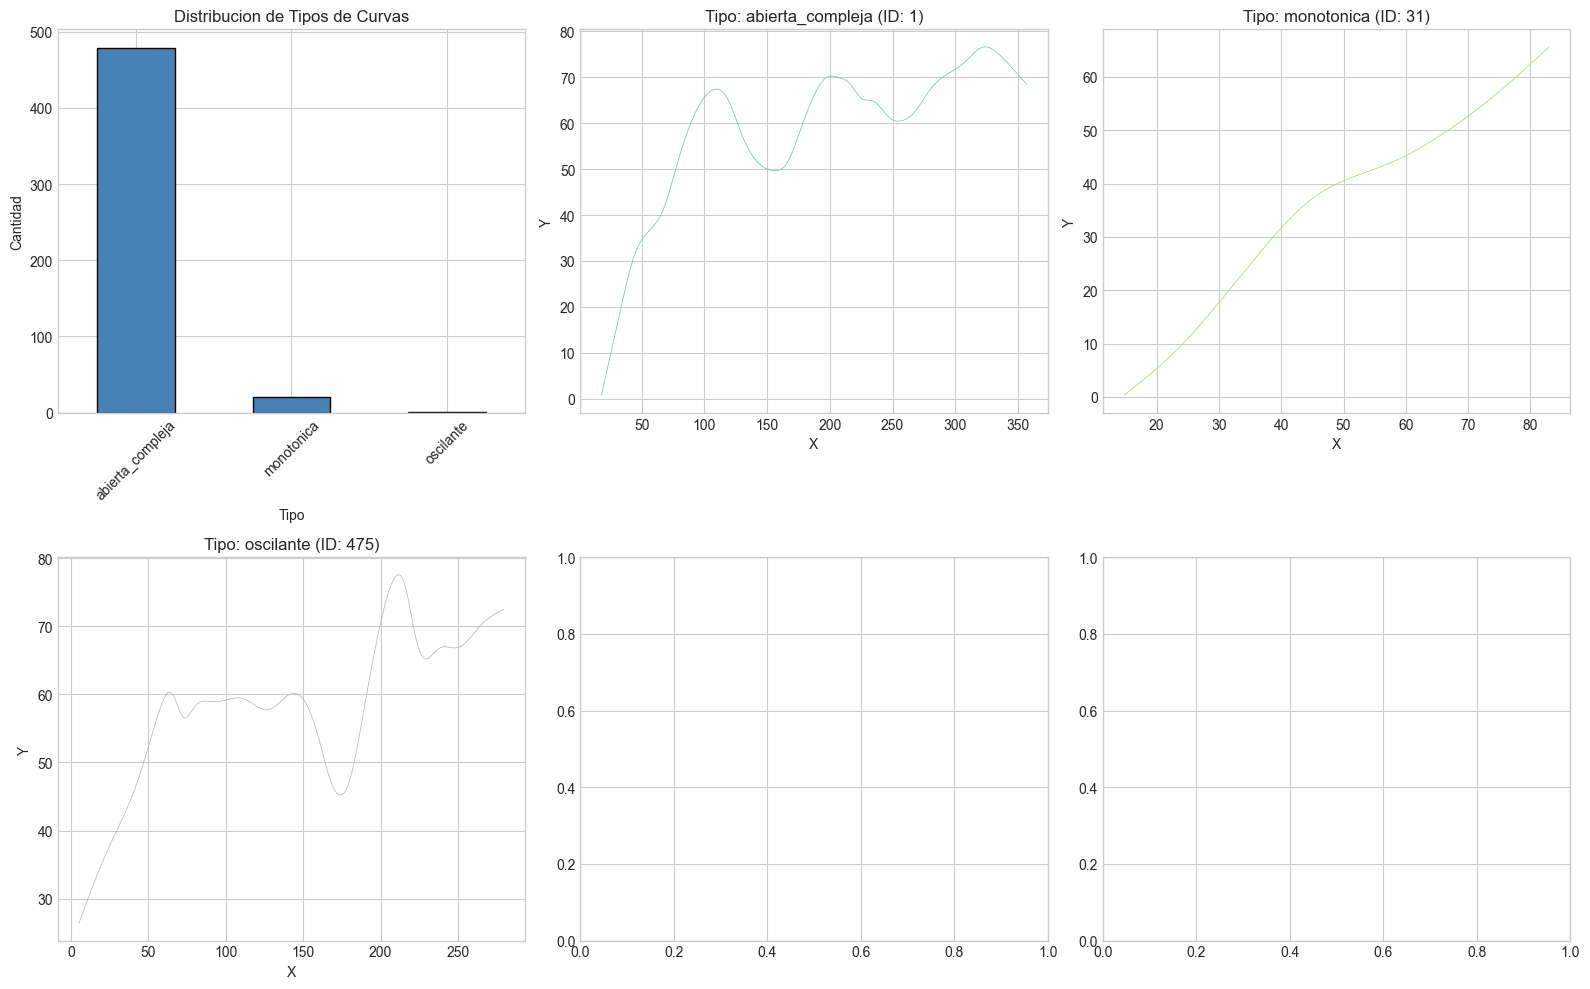

In [12]:
# Visualizacion de ejemplos por tipo
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Grafico de barras de tipos
type_counts.plot(kind='bar', ax=axes[0, 0], color='steelblue', edgecolor='black')
axes[0, 0].set_title('Distribucion de Tipos de Curvas')
axes[0, 0].set_xlabel('Tipo')
axes[0, 0].set_ylabel('Cantidad')
axes[0, 0].tick_params(axis='x', rotation=45)

# Mostrar un ejemplo de cada tipo
unique_types = df_types['type'].unique()
colors = plt.cm.Set2(np.linspace(0, 1, len(unique_types)))

for idx, curve_type in enumerate(unique_types[:5]):  # Max 5 tipos
    ax_idx = idx + 1
    row = ax_idx // 3
    col = ax_idx % 3
    
    example_id = df_types[df_types['type'] == curve_type]['curve_id'].iloc[0]
    x, y = target_data[example_id]['x'], target_data[example_id]['y']
    
    axes[row, col].plot(x, y, linewidth=0.5, color=colors[idx])
    axes[row, col].set_title(f'Tipo: {curve_type} (ID: {example_id})')
    axes[row, col].set_xlabel('X')
    axes[row, col].set_ylabel('Y')

plt.tight_layout()
plt.savefig('tipos_curvas.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Analisis de Puntos Criticos

In [13]:
def find_critical_points(x, y):
    """Encuentra puntos criticos: maximos, minimos, puntos de inflexion."""
    # Suavizar para reducir ruido
    y_smooth = gaussian_filter1d(y, sigma=10)
    
    # Maximos locales en Y
    y_maxima, _ = signal.find_peaks(y_smooth, distance=50)
    
    # Minimos locales en Y
    y_minima, _ = signal.find_peaks(-y_smooth, distance=50)
    
    # Puntos de inflexion (cambio de signo en segunda derivada)
    dy = np.gradient(y_smooth)
    ddy = np.gradient(dy)
    sign_changes = np.where(np.diff(np.sign(ddy)))[0]
    
    return {
        'y_maxima': y_maxima,
        'y_minima': y_minima,
        'inflection_points': sign_changes
    }

print("ANALISIS DE PUNTOS CRITICOS")
print("=" * 70)

# Analizar puntos criticos
critical_stats = []

for curve_id, data in target_data.items():
    critical = find_critical_points(data['x'], data['y'])
    
    stats_dict = {
        'curve_id': curve_id,
        'n_maxima': len(critical['y_maxima']),
        'n_minima': len(critical['y_minima']),
        'n_inflection': len(critical['inflection_points']),
        'n_extrema': len(critical['y_maxima']) + len(critical['y_minima'])
    }
    critical_stats.append(stats_dict)

df_critical = pd.DataFrame(critical_stats)

print("\nEstadisticas de puntos criticos:")
print(df_critical.describe().round(2).to_string())

ANALISIS DE PUNTOS CRITICOS

Estadisticas de puntos criticos:
       curve_id  n_maxima  n_minima  n_inflection  n_extrema
count    500.00    500.00    500.00        500.00     500.00
mean     250.50      2.32      1.88          8.10       4.21
std      144.48      1.28      1.29          3.57       2.50
min        1.00      0.00      0.00          1.00       0.00
25%      125.75      1.00      1.00          5.00       2.00
50%      250.50      2.00      2.00          8.00       4.00
75%      375.25      3.00      3.00         11.00       6.00
max      500.00      6.00      6.00         19.00      12.00


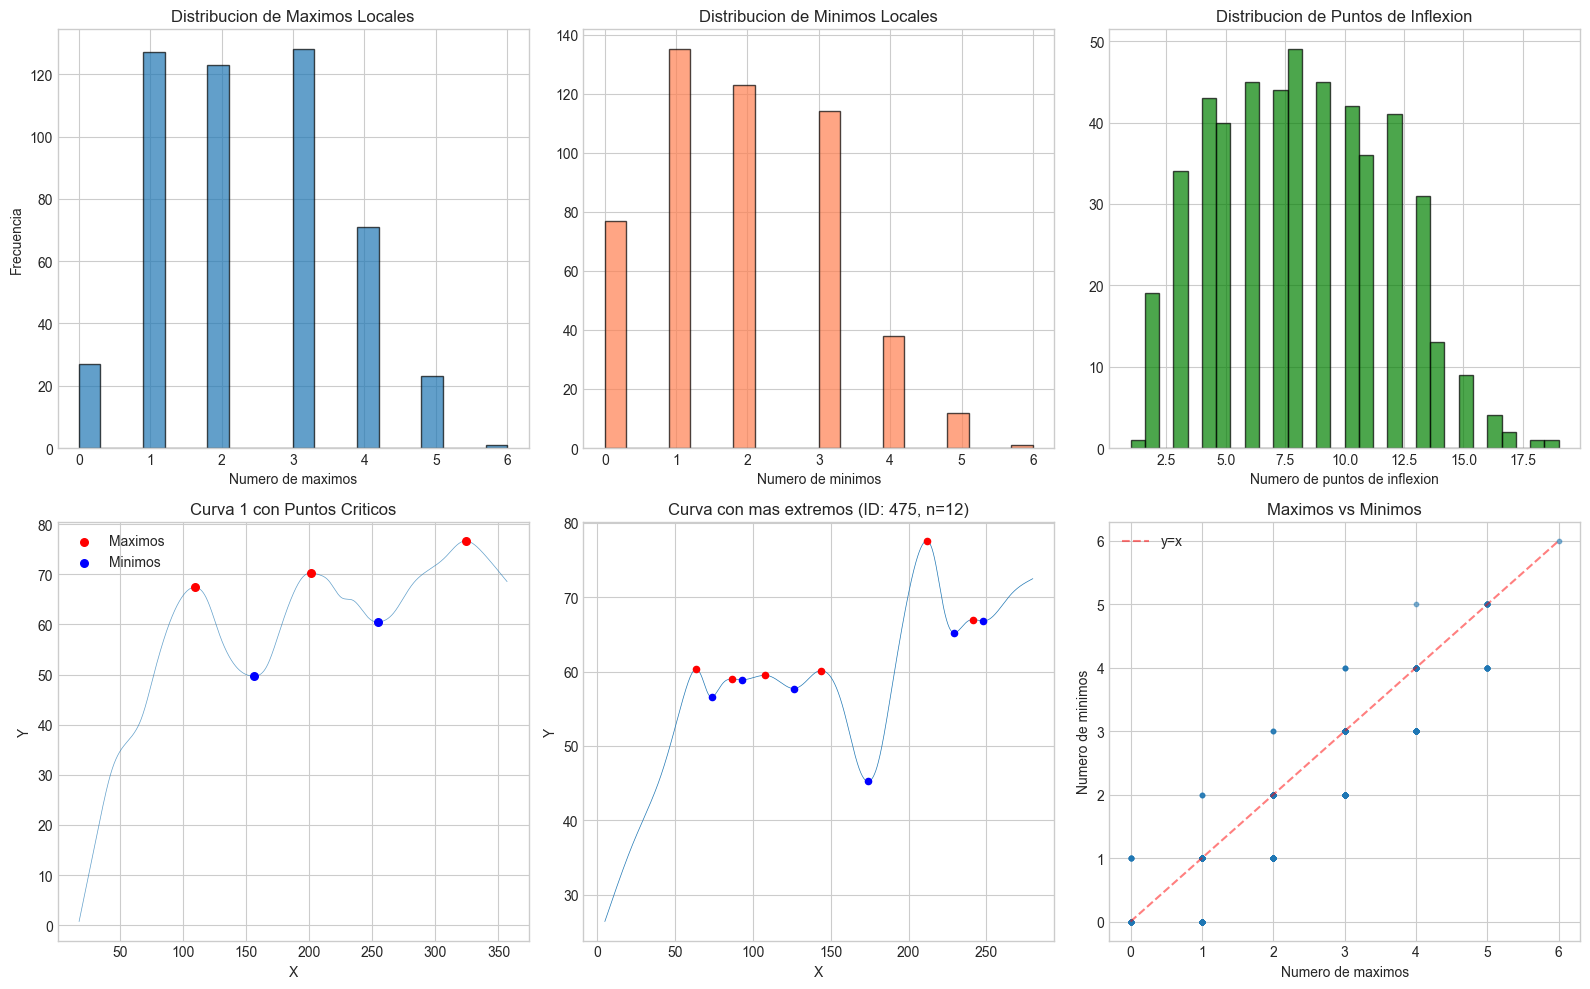

In [14]:
# Visualizacion de puntos criticos
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Distribucion de maximos
axes[0, 0].hist(df_critical['n_maxima'], bins=20, edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Distribucion de Maximos Locales')
axes[0, 0].set_xlabel('Numero de maximos')
axes[0, 0].set_ylabel('Frecuencia')

# Distribucion de minimos
axes[0, 1].hist(df_critical['n_minima'], bins=20, edgecolor='black', alpha=0.7, color='coral')
axes[0, 1].set_title('Distribucion de Minimos Locales')
axes[0, 1].set_xlabel('Numero de minimos')

# Distribucion de puntos de inflexion
axes[0, 2].hist(df_critical['n_inflection'], bins=30, edgecolor='black', alpha=0.7, color='green')
axes[0, 2].set_title('Distribucion de Puntos de Inflexion')
axes[0, 2].set_xlabel('Numero de puntos de inflexion')

# Ejemplo con puntos criticos marcados
example_id = 1
x, y = target_data[example_id]['x'], target_data[example_id]['y']
critical = find_critical_points(x, y)

axes[1, 0].plot(x, y, linewidth=0.5, alpha=0.7)
axes[1, 0].scatter(x[critical['y_maxima']], y[critical['y_maxima']], color='red', s=30, zorder=5, label='Maximos')
axes[1, 0].scatter(x[critical['y_minima']], y[critical['y_minima']], color='blue', s=30, zorder=5, label='Minimos')
axes[1, 0].set_title(f'Curva {example_id} con Puntos Criticos')
axes[1, 0].set_xlabel('X')
axes[1, 0].set_ylabel('Y')
axes[1, 0].legend()

# Curva con mas extremos
most_extrema_id = df_critical.loc[df_critical['n_extrema'].idxmax(), 'curve_id']
x, y = target_data[most_extrema_id]['x'], target_data[most_extrema_id]['y']
critical = find_critical_points(x, y)

axes[1, 1].plot(x, y, linewidth=0.5)
axes[1, 1].scatter(x[critical['y_maxima']], y[critical['y_maxima']], color='red', s=20, zorder=5)
axes[1, 1].scatter(x[critical['y_minima']], y[critical['y_minima']], color='blue', s=20, zorder=5)
axes[1, 1].set_title(f'Curva con mas extremos (ID: {most_extrema_id}, n={df_critical["n_extrema"].max()})')
axes[1, 1].set_xlabel('X')
axes[1, 1].set_ylabel('Y')

# Relacion maximos vs minimos
axes[1, 2].scatter(df_critical['n_maxima'], df_critical['n_minima'], alpha=0.5, s=10)
axes[1, 2].plot([0, df_critical['n_maxima'].max()], [0, df_critical['n_maxima'].max()], 'r--', alpha=0.5, label='y=x')
axes[1, 2].set_title('Maximos vs Minimos')
axes[1, 2].set_xlabel('Numero de maximos')
axes[1, 2].set_ylabel('Numero de minimos')
axes[1, 2].legend()

plt.tight_layout()
plt.savefig('puntos_criticos.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Resumen de Caracteristicas Geometricas

In [15]:
# Combinar todas las metricas en un DataFrame
print("RESUMEN COMPLETO DE CARACTERISTICAS GEOMETRICAS")
print("=" * 70)

df_geometric = df_lengths.merge(df_curvature, on='curve_id')
df_geometric = df_geometric.merge(df_slopes, on='curve_id')
df_geometric = df_geometric.merge(df_speed, on='curve_id')
df_geometric = df_geometric.merge(df_critical, on='curve_id')
df_geometric = df_geometric.merge(df_types, on='curve_id')

print(f"\nDataset de caracteristicas geometricas: {len(df_geometric)} curvas, {len(df_geometric.columns)} caracteristicas")
print(f"\nColumnas disponibles:")
for col in df_geometric.columns:
    print(f"  - {col}")

RESUMEN COMPLETO DE CARACTERISTICAS GEOMETRICAS

Dataset de caracteristicas geometricas: 500 curvas, 23 caracteristicas

Columnas disponibles:
  - curve_id
  - arc_length
  - curvature_mean
  - curvature_max
  - curvature_std
  - curvature_median
  - curvature_q95
  - slope_mean
  - slope_std
  - angle_mean
  - angle_std
  - angle_range
  - direction_changes
  - speed_mean
  - speed_std
  - speed_min
  - speed_max
  - speed_cv
  - n_maxima
  - n_minima
  - n_inflection
  - n_extrema
  - type


In [16]:
# Guardar dataset de caracteristicas
df_geometric.to_csv('caracteristicas_geometricas.csv', index=False)
print("\nDataset guardado en 'caracteristicas_geometricas.csv'")

print("\nResumen estadistico:")
print(df_geometric.describe().round(4).to_string())


Dataset guardado en 'caracteristicas_geometricas.csv'

Resumen estadistico:
       curve_id  arc_length  curvature_mean  curvature_max  curvature_std  curvature_median  curvature_q95  slope_mean  slope_std  angle_mean  angle_std  angle_range  direction_changes  speed_mean  speed_std  speed_min  speed_max  speed_cv  n_maxima  n_minima  n_inflection  n_extrema
count  500.0000    500.0000        500.0000       500.0000       500.0000          500.0000       500.0000    500.0000   500.0000    500.0000   500.0000     500.0000           500.0000    500.0000   500.0000   500.0000   500.0000  500.0000   500.000  500.0000      500.0000   500.0000
mean   250.5000    228.5219          0.0304         0.1596         0.0325            0.0196         0.0998      0.3126     0.7389     12.3620    29.7680      99.4802             4.2080      0.0286     0.0075     0.0162     0.0463    0.2593     2.324    1.8820        8.1020     4.2060
std    144.4818     90.6884          0.0092         0.0890         0

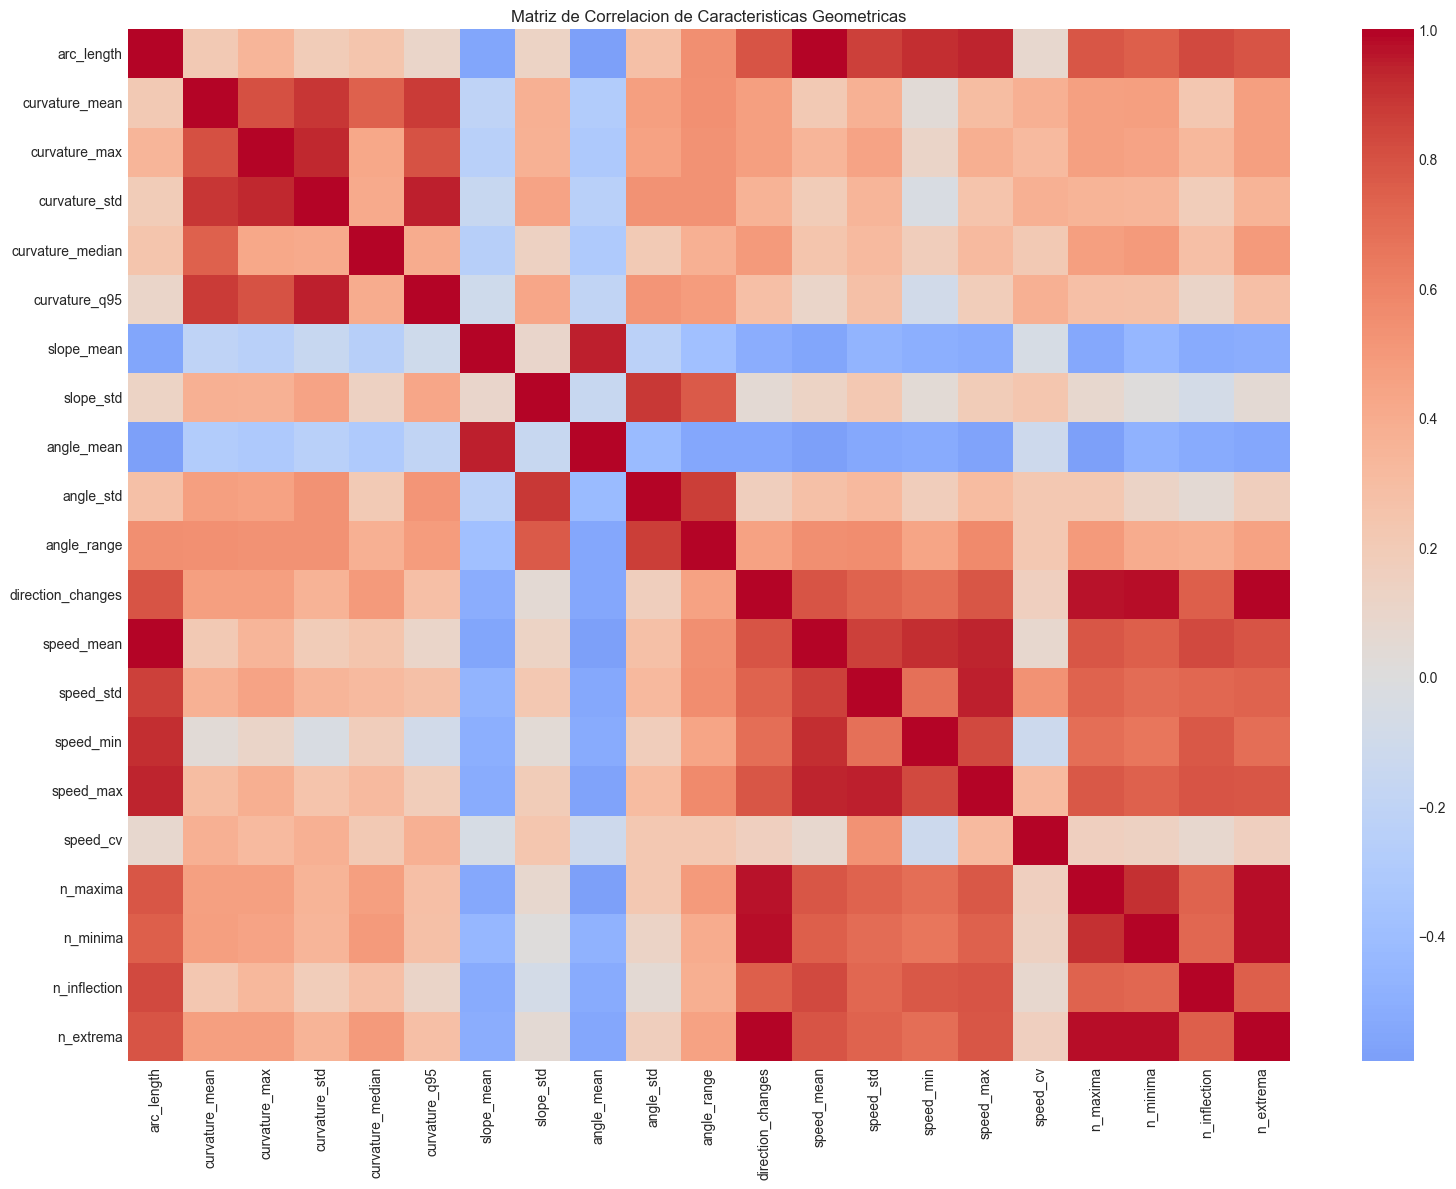

In [17]:
# Matriz de correlacion de caracteristicas numericas
numeric_cols = df_geometric.select_dtypes(include=[np.number]).columns.drop('curve_id')

plt.figure(figsize=(16, 12))
corr_matrix = df_geometric[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0)
plt.title('Matriz de Correlacion de Caracteristicas Geometricas')
plt.tight_layout()
plt.savefig('correlacion_geometricas.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Conclusiones del Analisis Geometrico

### Hallazgos Principales:

1. **Longitud de Arco:**
   - Gran variabilidad en longitudes (ratio max/min > 2x)
   - Longitud no correlaciona con ID de curva

2. **Curvatura:**
   - La mayoria de curvas tienen curvatura moderada
   - Algunas curvas presentan picos de alta curvatura (giros cerrados)

3. **Direccion y Pendientes:**
   - Numero variable de cambios de direccion entre curvas
   - Pocas curvas son estrictamente monotonicas

4. **Velocidad Parametrica:**
   - La mayoria de curvas tienen velocidad relativamente uniforme
   - Esto sugiere parametrizacion cercana a longitud de arco

5. **Tipos de Curvas:**
   - Predominan curvas abiertas complejas
   - Pocas curvas cerradas o con loops
   - Varias curvas muestran comportamiento oscilante

6. **Puntos Criticos:**
   - Numero balanceado de maximos y minimos
   - Sugiere comportamiento ondulatorio tipico